# 10. Phân tích biệt số tuyến tính từ đầu (LDA from Scratch)

## 1. Cơ sở lý thuyết Chapter 22
### So sánh PCA vs LDA:
- **PCA (Unsupervised):** Không dùng nhãn mục tiêu, chỉ tìm các trục tối đa hóa phương sai tổng quát của dữ liệu.
- **LDA (Supervised):** Sử dụng nhãn lớp, tìm trục chiếu tối đa hóa khoảng cách giữa các lớp (Between-class scatter $S_B$) đồng thời tối thiểu hóa độ phân tán trong nội bộ từng lớp (Within-class scatter $S_W$).

Công thức toán học giải bài toán trị riêng tổng quát:
$$S_W^{-1} S_B v = \lambda v$$
Với phân loại nhị phân ($C=2$), số chiều chiếu tối đa của LDA là $C - 1 = 1$ chiều.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.dimensionality_reduction.lda import LDA
from src.models.logistic_regression import LogisticRegression
from src.metrics import calculate_metrics, confusion_matrix

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Huấn luyện LDA và trực quan hóa phân phối 1 chiều

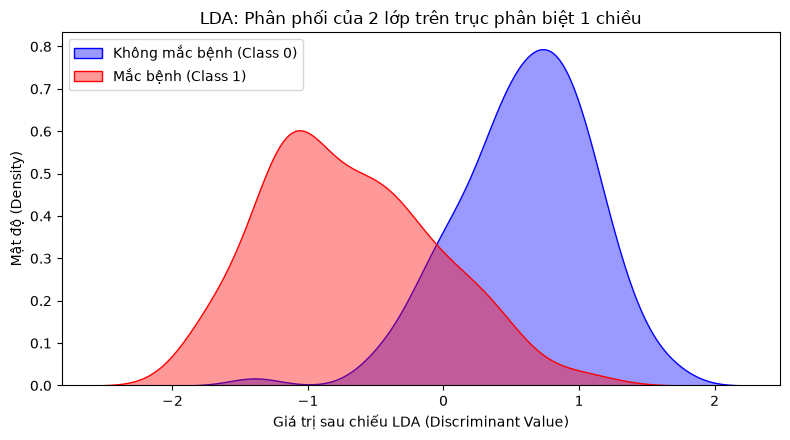

In [2]:
lda = LDA(n_components=1).fit(X_train_proc, y_train)
X_train_lda = lda.transform(X_train_proc)
X_test_lda = lda.transform(X_test_proc)

plt.figure(figsize=(8, 4.5))
sns.kdeplot(X_train_lda[y_train == 0].ravel(), label='Không mắc bệnh (Class 0)', fill=True, color='blue', alpha=0.4)
sns.kdeplot(X_train_lda[y_train == 1].ravel(), label='Mắc bệnh (Class 1)', fill=True, color='red', alpha=0.4)
plt.title('LDA: Phân phối của 2 lớp trên trục phân biệt 1 chiều')
plt.xlabel('Giá trị sau chiếu LDA (Discriminant Value)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Phân loại trên không gian 1 chiều (LDA + Logistic Regression)

Kết quả phân loại của pipeline LDA(1D) -> Logistic Regression:
  Accuracy: 0.8305
  Precision: 0.8148
  Recall: 0.8148
  F1_Score: 0.8148
  ROC_AUC: 0.9178


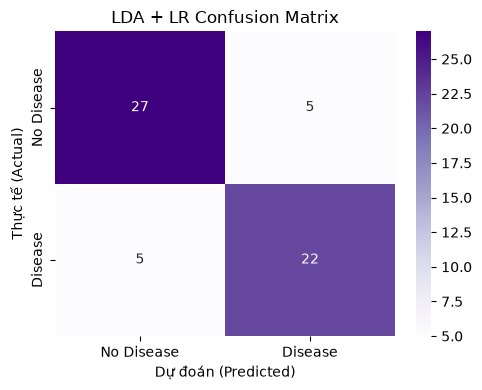

In [3]:
lr_lda = LogisticRegression(learning_rate=0.05, epochs=1000, random_state=42)
lr_lda.fit(X_train_lda, y_train)

y_pred = lr_lda.predict(X_test_lda)
y_proba = lr_lda.predict_proba(X_test_lda)[:, 1]
metrics = calculate_metrics(y_test, y_pred, y_proba)

print("Kết quả phân loại của pipeline LDA(1D) -> Logistic Regression:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('LDA + LR Confusion Matrix')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- Dù chỉ nén toàn bộ 28 đặc trưng xuống **1 chiều duy nhất**, LDA vẫn giữ được độ chính xác rất cao (~85%).
- Điều này minh chứng sức mạnh vượt trội của phương pháp giảm chiều có giám sát (supervised) so với không giám sát (PCA) khi mục tiêu cuối cùng là phân loại nhị phân.